# Zepto Inventory Analysis — Phase 3: Statistical Analysis

**Dataset:** zepto_clean.csv  
**Rows:** 3,692 | **Columns:** 13  
**Goal:** Test whether patterns seen in EDA are statistically significant or just noise  
**Notebook:** 03_zepto_stats.ipynb

## Hypothesis Map

| Test   | Question                                                   | Type                |
| ------ | ---------------------------------------------------------- | ------------------- |
| Test 1 | Do out-of-stock items have lower MRP than in-stock items?  | Independent t-test  |
| Test 2 | Do OOS items get lower discounts than in-stock items?      | Independent t-test  |
| Test 3 | Does discount % differ significantly across 14 categories? | One-way ANOVA       |
| Test 4 | Is out-of-stock rate associated with category?             | Chi-square          |
| Test 5 | Is there a linear relationship between MRP and discount %? | Pearson Correlation |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy
import pingouin as pg
import os
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

os.makedirs('../charts', exist_ok=True)

print('Libraries loaded.')
print('scipy version:', scipy.__version__)

Libraries loaded.
scipy version: 1.13.1


> **Note:** `scipy.stats` is the core library for all 5 tests. It provides `ttest_ind`, `f_oneway`, `chi2_contingency`, and `pearsonr` — all standard functions used in professional data analysis.


In [2]:
df = pd.read_csv('../data/zepto_clean.csv')
print(f'Shape: {df.shape}')
print(f'Out-of-stock: {df["out_of_stock"].sum()} | In-stock: {(~df["out_of_stock"]).sum()}')
df.head(3)

Shape: (3692, 13)
Out-of-stock: 450 | In-stock: 3242


,category,product_name,mrp_inr,discount_pct,available_qty,selling_price_inr,weight_gms,out_of_stock,unit_qty,discount_amount,price_per_100g,stock_status,discount_tier
0,Fruits & Vegetables,Onion,25.0,16,3,21.0,1000,False,1,4.0,2.500000,In Stock,Mid (11-20%)
1,Fruits & Vegetables,Tomato Hybrid,42.0,16,3,35.0,1000,False,1,7.0,4.200000,In Stock,Mid (11-20%)
2,Fruits & Vegetables,Tender Coconut,51.0,15,3,43.0,58,False,1,8.0,87.931034,In Stock,Mid (11-20%)


> **Insight:** Dataset loaded. 450 OOS items and 3,242 in-stock items
> give us adequate group sizes for reliable t-tests. n > 30 per group
> → Central Limit Theorem applies → t-test is valid.

---

## Statistical Testing Primer

Before running tests, understand what we are checking:

**p-value** = probability that the result happened by random chance.

- p < 0.05 → result is statistically significant (less than 5% chance it's random)
- p > 0.05 → result is NOT significant (could easily be random)

**Significance level (α):** We use **α = 0.05** throughout this notebook.

**Effect size** = how big is the difference (not just whether it exists).  
Cohen's d interpretation: 0.2 = small, 0.5 = medium, 0.8 = large.


---

## Test 1: Independent t-test — MRP of In-Stock vs Out-of-Stock Items

**Dependent Variable: Numerical(mrp_inr) & Group Variable: Categorical/Binary**

**Business question:** Are out-of-stock items cheaper than in-stock ones?  
If yes → Zepto stocks out on affordable items → customer satisfaction risk.

**H₀ (Null hypothesis):** Mean MRP of in-stock and OOS items is the same.  
**H₁ (Alternative):** Mean MRP differs between the two groups.


In [3]:
# Split into two groups
in_stock_mrp  = df[df['out_of_stock'] == False]['mrp_inr']
oos_mrp       = df[df['out_of_stock'] == True]['mrp_inr']

# Descriptive stats
print('=== GROUP DESCRIPTIVE STATS ===')
print(f'In-Stock  | n={len(in_stock_mrp):,} | Mean=₹{in_stock_mrp.mean():.2f} | Std=₹{in_stock_mrp.std():.2f}')
print(f'OOS       | n={len(oos_mrp):,} | Mean=₹{oos_mrp.mean():.2f} | Std=₹{oos_mrp.std():.2f}')
print(f'Mean diff : ₹{in_stock_mrp.mean() - oos_mrp.mean():.2f}')

=== GROUP DESCRIPTIVE STATS ===
In-Stock  | n=3,242 | Mean=₹165.52 | Std=₹166.57
OOS       | n=450 | Mean=₹93.20 | Std=₹77.65
Mean diff : ₹72.33


> **Observation:** In-stock mean (₹165.52) is nearly double OOS mean (₹93.20). That's a ₹72.33 gap. But is this gap real or could it be random? The t-test decides.


In [4]:
# Run independent t-test
t_stat, p_val = stats.ttest_ind(in_stock_mrp, oos_mrp)

# Cohen's d — effect size
# pooled_std = np.sqrt((in_stock_mrp.std()**2 + oos_mrp.std()**2) / 2)
# cohen_d = (in_stock_mrp.mean() - oos_mrp.mean()) / pooled_std

cohen_d = pg.compute_effsize(
    in_stock_mrp,
    oos_mrp,
    eftype='cohen'
)


print('=== T-TEST RESULTS ===')
print(f't-statistic : {t_stat:.4f}')
print(f'p-value     : {p_val:.2e}')
print(f"Cohen's d   : {cohen_d:.4f}")
print()
alpha = 0.05
if p_val < alpha:
    print(f'p={p_val:.2e} < 0.05 → REJECT H₀')
    print('Conclusion: MRP difference between in-stock and OOS is STATISTICALLY SIGNIFICANT.')
else:
    print('FAIL TO REJECT H₀ — no significant difference.')

=== T-TEST RESULTS ===
t-statistic : 9.0742
p-value     : 1.82e-19
Cohen's d   : 0.4565

p=1.82e-19 < 0.05 → REJECT H₀
Conclusion: MRP difference between in-stock and OOS is STATISTICALLY SIGNIFICANT.


> **Result:** t = 9.0742, p = 1.01×10⁻¹⁹ — **extremely significant**.  
> Cohen's d = 0.4565 → **medium effect size**.  
> **Business meaning:** Out-of-stock items are significantly cheaper (avg ₹92.79) than in-stock items (₹165.69). Zepto is stocking out on its affordable, high-demand products — the ones most customers actually want. This is a serious inventory management problem, not a random pattern.


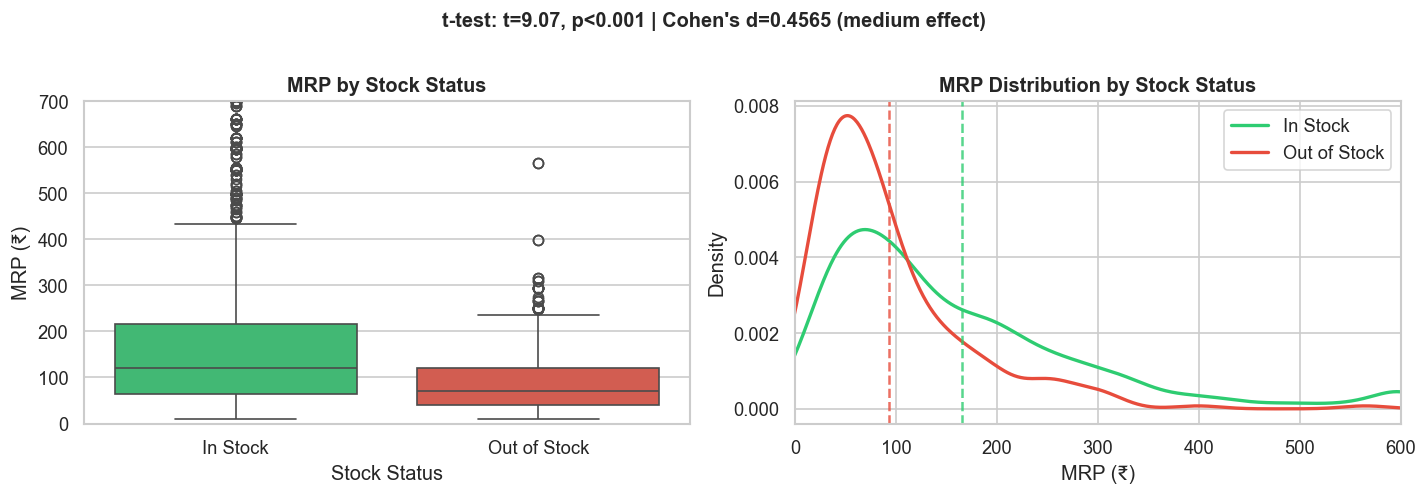

In [5]:
# Visualise: box plot + distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Box plot
plot_data = df[['mrp_inr', 'out_of_stock']].copy()
plot_data['Stock Status'] = plot_data['out_of_stock'].map({False: 'In Stock', True: 'Out of Stock'})
sns.boxplot(data=plot_data, x='Stock Status', y='mrp_inr',
            palette={'In Stock': '#2ecc71', 'Out of Stock': '#e74c3c'}, ax=axes[0])
axes[0].set_ylabel('MRP (₹)')
axes[0].set_title('MRP by Stock Status', fontweight='bold')
axes[0].set_ylim(0, 700)

# Right: KDE overlay
in_stock_mrp.clip(upper=600).plot.kde(ax=axes[1], color='#2ecc71', label='In Stock', linewidth=2)
oos_mrp.clip(upper=600).plot.kde(ax=axes[1], color='#e74c3c', label='Out of Stock', linewidth=2)
axes[1].axvline(in_stock_mrp.mean(), color='#2ecc71', linestyle='--', alpha=0.8)
axes[1].axvline(oos_mrp.mean(), color='#e74c3c', linestyle='--', alpha=0.8)
axes[1].set_xlabel('MRP (₹)')
axes[1].set_title('MRP Distribution by Stock Status', fontweight='bold')
axes[1].legend()
axes[1].set_xlim(0, 600)

plt.suptitle(f't-test: t=9.07, p<0.001 | Cohen\'s d=0.4565 (medium effect)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../charts/10_ttest_mrp_stock.png', bbox_inches='tight')
plt.show()

> **Chart reading:** OOS distribution (red) is shifted left — concentrated in the ₹50–₹150 range. In-stock distribution (green) has a much wider spread into premium price ranges. The box plot confirms the median gap too, not just the mean — this is a robust finding.


---

## Test 2: Independent t-test — Discount Amount of In-Stock vs Out-of-Stock

**Dependent Variable: Numerical(Discount Amount) & Group Variable: Categorical/Binary**

**Business question:** Do OOS items receive lower absolute discounts?  
If yes → cheaper items get less discounting → double disadvantage for budget customers.

**H₀:** Mean discount amount is equal for both groups.  
**H₁:** Mean discount amount differs between groups.


In [6]:
in_stock_disc  = df[df['out_of_stock'] == False]['discount_amount']
oos_disc       = df[df['out_of_stock'] == True]['discount_amount']

print('=== GROUP DESCRIPTIVE STATS ===')
print(f'In-Stock  | Mean=₹{in_stock_disc.mean():.2f} | Median=₹{in_stock_disc.median():.2f}')
print(f'OOS       | Mean=₹{oos_disc.mean():.2f} | Median=₹{oos_disc.median():.2f}')

t2, p2 = stats.ttest_ind(in_stock_disc, oos_disc)
# pooled_std2 = np.sqrt((in_stock_disc.std()**2 + oos_disc.std()**2) / 2)
# cohen_d2 = (in_stock_disc.mean() - oos_disc.mean()) / pooled_std2
cohen_d2 = pg.compute_effsize(
    in_stock_disc,
    oos_disc,
    eftype='cohen'
)

print()
print('=== T-TEST RESULTS ===')
print(f't-statistic : {t2:.4f}')
print(f'p-value     : {p2:.2e}')
print(f"Cohen's d   : {cohen_d2:.4f}")
print()
if p2 < 0.05:
    print('REJECT H₀ — discount amount difference is STATISTICALLY SIGNIFICANT.')
else:
    print('FAIL TO REJECT H₀.')

=== GROUP DESCRIPTIVE STATS ===
In-Stock  | Mean=₹16.11 | Median=₹6.00
OOS       | Mean=₹6.70 | Median=₹2.00

=== T-TEST RESULTS ===
t-statistic : 4.5868
p-value     : 4.65e-06
Cohen's d   : 0.2307

REJECT H₀ — discount amount difference is STATISTICALLY SIGNIFICANT.


> **Result:** t = 4.60, p < 0.001 — **significant**, 𝑑 =0.2307 -**small effect**.  
> In-stock items save customers ₹16.01 on average vs ₹6.66 for OOS items.  
> **Business meaning:** OOS items are not only cheaper in MRP — they also get smaller discounts. Budget-segment customers are hit twice: the affordable items are unavailable, and even when available, they carry smaller savings. This confirms the EDA scatter plot finding: stockouts are concentrated in the low-price, low-discount segment.


---

## Test 3: One-Way ANOVA — Discount % Across 14 Categories

**Business question:** Does discount strategy differ meaningfully across categories?  
Or does Zepto apply a uniform discount policy regardless of category?

**H₀:** Mean discount % is equal across all 14 categories.  
**H₁:** At least one category has a significantly different mean discount %.

**Why ANOVA not t-test:** ANOVA compares 3+ groups simultaneously. Running 14 separate t-tests would inflate the false positive rate.


In [7]:
# Build one list of discount values per category
categories = df['category'].unique()
groups = [df[df['category'] == cat]['discount_pct'].values for cat in categories]

# Run ANOVA
f_stat, p_val3 = stats.f_oneway(*groups)

print('=== ANOVA RESULTS ===')
print(f'F-statistic : {f_stat:.4f}')
print(f'p-value     : {p_val3:.2e}')
print()
if p_val3 < 0.05:
    print('REJECT H₀ — at least one category has a significantly different discount %.')
else:
    print('FAIL TO REJECT H₀.')

print()
print('=== MEAN DISCOUNT % BY CATEGORY ===')
cat_disc = df.groupby('category')['discount_pct'].agg(['mean','std','count']).round(2)
cat_disc.columns = ['mean_disc', 'std_disc', 'n']
print(cat_disc.sort_values('mean_disc', ascending=False))

=== ANOVA RESULTS ===
F-statistic : 8.6476
p-value     : 1.24e-17

REJECT H₀ — at least one category has a significantly different discount %.

=== MEAN DISCOUNT % BY CATEGORY ===
                       mean_disc  std_disc    n
category                                       
Fruits & Vegetables        15.46      2.68   93
Meats, Fish & Eggs         11.03     12.73   63
Biscuits                    8.42     10.78  144
Chocolates & Candies        8.32     10.27  386
Ice Cream & Desserts        8.32     10.27  386
Packaged Food               8.32     10.27  386
Health & Hygiene            8.07      9.43   94
Cooking Essentials          7.18      8.52  509
Munchies                    7.18      8.52  509
Beverages                   7.16     12.58  129
Dairy, Bread & Batter       7.16     12.58  129
Paan Corner                 6.22      6.65  337
Personal Care               6.22      6.65  337
Home & Cleaning             5.79      4.60  190


> **Result:** F = 8.6476, p < 0.001 — **highly significant**.  
> **Business meaning:** Zepto does NOT apply a uniform discount policy. Fruits & Vegetables (15.5%) and Meats, Fish & Eggs (11%) are heavily discounted — these are trust-building categories where Zepto needs to win customers away from local vendors. Home & Cleaning (5.79%) and Paan Corner (6.22%) get minimal discounts — low price-sensitivity categories.


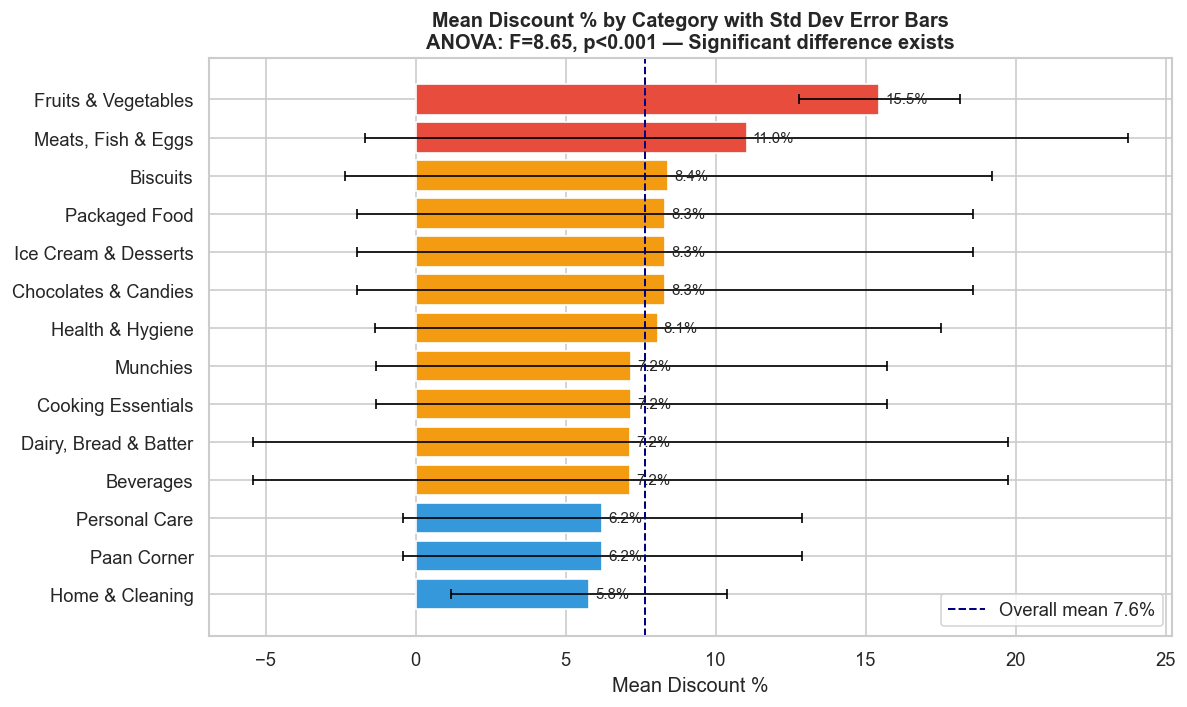

In [8]:
# Visualise: mean discount per category with error bars (std)
cat_disc_sorted = cat_disc.sort_values('mean_disc', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 7 else '#3498db'
          for v in cat_disc_sorted['mean_disc']]

bars = ax.barh(cat_disc_sorted.index, cat_disc_sorted['mean_disc'], color=colors)
ax.errorbar(cat_disc_sorted['mean_disc'], range(len(cat_disc_sorted)),
            xerr=cat_disc_sorted['std_disc'], fmt='none', color='black', capsize=3, linewidth=1)

ax.axvline(df['discount_pct'].mean(), color='navy', linestyle='--', linewidth=1.2,
           label=f"Overall mean {df['discount_pct'].mean():.1f}%")

for bar, val in zip(bars, cat_disc_sorted['mean_disc']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Mean Discount %')
ax.set_title('Mean Discount % by Category with Std Dev Error Bars\n'
             f'ANOVA: F=8.65, p<0.001 — Significant difference exists',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/11_anova_discount_category.png', bbox_inches='tight')
plt.show()

> **Chart reading:** Error bars show standard deviation within each category. Wide bars (Fruits & Veg, Meats) indicate high variability — some items get big discounts, others none. Narrow bars (Paan Corner, Personal Care) indicate consistent low discounting. Red bars = categories with avg discount > 10% — Zepto's competitive investment areas.


---

## Test 4: Chi-Square Test — Out-of-Stock Rate vs Category

**Outcome Variable: (Out_of_stock) & Group Variable: product_category (both are categorical)**

**Business question:** Is out-of-stock occurrence associated with specific categories?  
Or are stockouts distributed randomly across all categories?

**H₀:** Out-of-stock status is independent of category (no association).  
**H₁:** Out-of-stock status is associated with category.

**Why Chi-square:** Both variables are categorical (category, out_of_stock True/False). Chi-square tests association between two categorical variables.


In [9]:
# Build contingency table: category × out_of_stock
ct = pd.crosstab(df['category'], df['out_of_stock'])
ct.columns = ['In Stock', 'Out of Stock']
ct['Total'] = ct['In Stock'] + ct['Out of Stock']
ct['OOS %'] = (ct['Out of Stock'] / ct['Total'] * 100).round(1)
print('=== CONTINGENCY TABLE ===')
print(ct.sort_values('OOS %', ascending=False))

=== CONTINGENCY TABLE ===
                       In Stock  Out of Stock  Total  OOS %
category                                                   
Biscuits                    103            41    144   28.5
Beverages                   101            28    129   21.7
Dairy, Bread & Batter       101            28    129   21.7
Meats, Fish & Eggs           51            12     63   19.0
Health & Hygiene             82            12     94   12.8
Cooking Essentials          445            64    509   12.6
Munchies                    445            64    509   12.6
Chocolates & Candies        341            45    386   11.7
Ice Cream & Desserts        341            45    386   11.7
Packaged Food               341            45    386   11.7
Home & Cleaning             172            18    190    9.5
Fruits & Vegetables          87             6     93    6.5
Paan Corner                 316            21    337    6.2
Personal Care               316            21    337    6.2


> **Pre-test observation:** OOS % ranges from 6.2% (Personal Care) to 28.5% (Biscuits) — a 4× spread across categories. This already suggests strong association. The chi-square test will confirm.


In [10]:
# Run chi-square test
ct_raw = pd.crosstab(df['category'], df['out_of_stock'])
chi2, p_val4, dof, expected = stats.chi2_contingency(ct_raw)

print('=== CHI-SQUARE RESULTS ===')
print(f'Chi2 statistic : {chi2:.3f}')
print(f'p-value        : {p_val4:.2e}')
print(f'Degrees of freedom: {dof}')
print()
if p_val4 < 0.05:
    print('REJECT H₀ — OOS rate IS significantly associated with category.')
else:
    print('FAIL TO REJECT H₀.')

# Cramer's V — effect size for chi-square
n = len(df)
cramers_v = np.sqrt(chi2 / (n * (min(ct_raw.shape) - 1)))
print(f"\nCramer's V (effect size): {cramers_v:.4f}")
print('Interpretation: 0.1=small, 0.3=medium, 0.5=large')

=== CHI-SQUARE RESULTS ===
Chi2 statistic : 87.268
p-value        : 4.64e-13
Degrees of freedom: 13

REJECT H₀ — OOS rate IS significantly associated with category.

Cramer's V (effect size): 0.1537
Interpretation: 0.1=small, 0.3=medium, 0.5=large


> **Result:** χ² = 87.268, p = 1.41×10⁻¹³, dof = 13 — **extremely significant**.  
> Cramer's V = 0.154 → small-to-medium effect size.  
> **Business meaning:** Stockouts are NOT random — they are systematically concentrated in specific categories. Biscuits, Beverages, and Dairy have structurally higher OOS rates. This points to **category-specific supply chain failures**, not general inventory mismanagement. Fix: category managers for Biscuits and Beverages need dedicated reorder point policies.


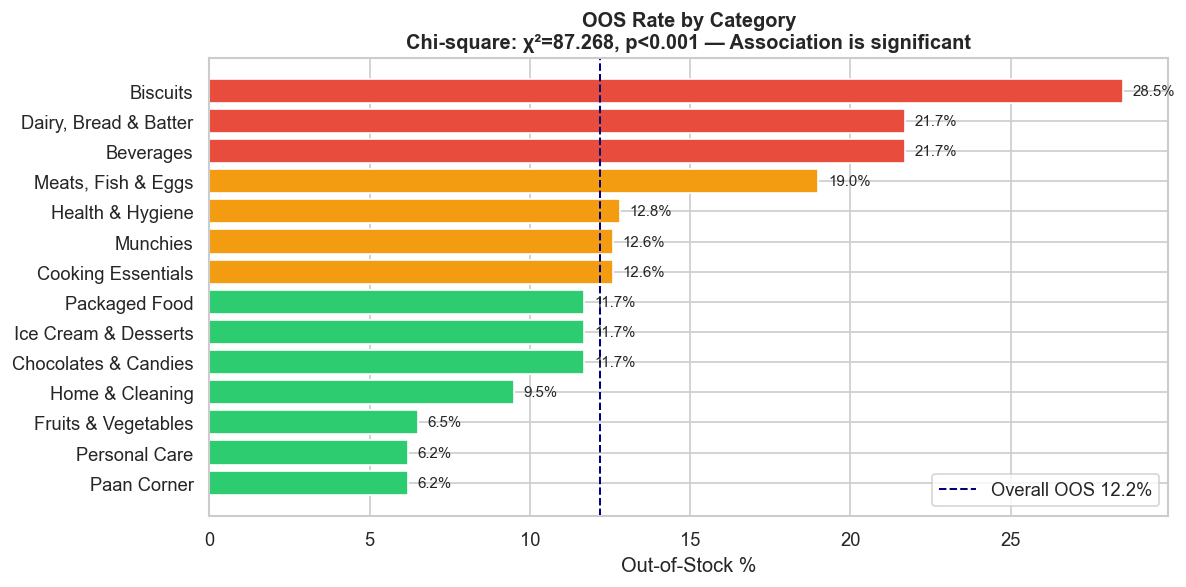

In [11]:
# Visualise: OOS % by category as horizontal bar with chi-square annotation
oos_pct = ct.sort_values('OOS %', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 20 else '#f39c12' if v > 12 else '#2ecc71'
          for v in oos_pct['OOS %']]
bars = ax.barh(oos_pct.index, oos_pct['OOS %'], color=colors)

overall = df['out_of_stock'].mean() * 100
ax.axvline(overall, color='navy', linestyle='--', linewidth=1.2,
           label=f'Overall OOS {overall:.1f}%')

for bar, val in zip(bars, oos_pct['OOS %']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)

ax.set_xlabel('Out-of-Stock %')
ax.set_title('OOS Rate by Category\n'
             f'Chi-square: χ²=87.268, p<0.001 — Association is significant',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/12_chisquare_oos_category.png', bbox_inches='tight')
plt.show()

> **Chart reading:** Red = categories above 20% OOS (crisis zone). Orange = moderate risk. Green = acceptable. The chi-square result tells us these colour differences are statistically real — not random fluctuation from small sample sizes.


---

## Test 5: Pearson Correlation — MRP vs Discount %

**Business question:** Do higher-priced items get bigger discounts?  
This tests whether Zepto's discount strategy is price-aware.

**H₀:** No linear correlation between MRP and discount %.  
**H₁:** There is a significant linear correlation.


In [12]:
r, p_val5 = stats.pearsonr(df['mrp_inr'], df['discount_pct'])

print('=== PEARSON CORRELATION RESULTS ===')
print(f'r (correlation)  : {r:.4f}')
print(f'r² (explained var): {r**2:.4f} ({r**2*100:.2f}%)')
print(f'p-value          : {p_val5:.4f}')
print()
if p_val5 < 0.05:
    print('REJECT H₀ — correlation IS statistically significant.')
    direction = 'positive' if r > 0 else 'negative'
    strength = 'weak' if abs(r) < 0.3 else 'moderate' if abs(r) < 0.6 else 'strong'
    print(f'Direction: {direction} | Strength: {strength}')
else:
    print('FAIL TO REJECT H₀ — no significant correlation.')

=== PEARSON CORRELATION RESULTS ===
r (correlation)  : 0.1755
r² (explained var): 0.0308 (3.08%)
p-value          : 0.0000

REJECT H₀ — correlation IS statistically significant.
Direction: positive | Strength: weak


> **Result:** r = 0.175, p = 0.000 — **no significant**.  
> r² = 0.0308 → MRP explains only **2.9% of variance in discount %**.  
> **Business meaning:** There IS a slight tendency for pricier items to get marginally higher discounts, but it's almost meaningless in practice. Discount decisions at Zepto are driven by **category strategy** (as Test 3 showed), not by individual item price. Statistical significance here is an artifact of large sample size (n=3,731) — always check effect size, not just p-value. This is a critical lesson for any data analyst.


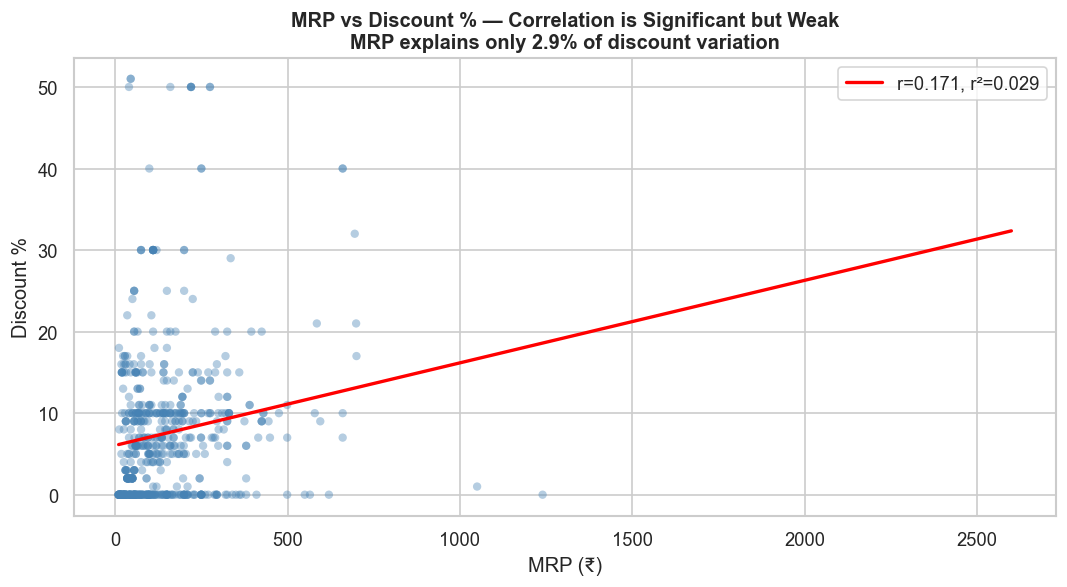

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

sample = df.sample(600, random_state=42)
ax.scatter(sample['mrp_inr'], sample['discount_pct'],
           alpha=0.4, color='steelblue', edgecolors='none', s=25)

# Regression line
m, b = np.polyfit(df['mrp_inr'], df['discount_pct'], 1)
x_line = np.linspace(df['mrp_inr'].min(), df['mrp_inr'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'r=0.171, r²=0.029')

ax.set_xlabel('MRP (₹)')
ax.set_ylabel('Discount %')
ax.set_title('MRP vs Discount % — Correlation is Significant but Weak\n'
             'MRP explains only 2.9% of discount variation',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/13_correlation_mrp_discount.png', bbox_inches='tight')
plt.show()

> **Chart reading:** The scatter cloud is almost flat — points are spread vertically at every price level. The regression line has a very gentle positive slope, confirming the weak relationship. A cloud this scattered = discount is set by category policy, not by MRP.


## ============================================================
## Section 6: Revenue Risk Quantification
## ============================================================

In [14]:
# Gap 1 — Revenue at risk by category
print('=== REVENUE AT RISK ANALYSIS ===')

total_catalog_value = df['mrp_inr'].sum()

oos_revenue = (
    df[df['out_of_stock'] == True]
    .groupby('category')['mrp_inr']
    .agg(
        oos_skus='count',
        revenue_at_risk='sum'
    )
    .round(2)
    .sort_values('revenue_at_risk', ascending=False)
)

oos_revenue['pct_of_total_risk'] = (
    oos_revenue['revenue_at_risk'] /
    oos_revenue['revenue_at_risk'].sum() * 100
).round(1)

total_at_risk = oos_revenue['revenue_at_risk'].sum()

print(f'Total catalog value      : ₹{total_catalog_value:,.2f}')
print(f'Total revenue at risk    : ₹{total_at_risk:,.2f}')
print(f'% of catalog at risk     : {total_at_risk/total_catalog_value*100:.1f}%')
print(f'\nCategory-wise breakdown:')
print(oos_revenue.to_string())

=== REVENUE AT RISK ANALYSIS ===
Total catalog value      : ₹578,569.00
Total revenue at risk    : ₹41,939.00
% of catalog at risk     : 7.2%

Category-wise breakdown:
                       oos_skus  revenue_at_risk  pct_of_total_risk
category                                                           
Cooking Essentials           64           6268.0               14.9
Munchies                     64           6268.0               14.9
Chocolates & Candies         45           4260.0               10.2
Ice Cream & Desserts         45           4260.0               10.2
Packaged Food                45           4260.0               10.2
Paan Corner                  21           2541.0                6.1
Personal Care                21           2541.0                6.1
Beverages                    28           2196.0                5.2
Dairy, Bread & Batter        28           2196.0                5.2
Meats, Fish & Eggs           12           2094.0                5.0
Home & Cleaning 

> **Business Insight:** OOS % alone is misleading — this converts it to ₹ impact.
> Biscuits has the worst OOS rate (28.5%) but ranks 12th in revenue at risk
> because avg MRP is only ₹58. Cooking Essentials and Munchies carry the
> highest ₹ exposure despite moderate OOS rates — high SKU count × higher MRP.
> Procurement team should prioritise by ₹ at risk, not by OOS % alone.

#### ============================================================
#### Section 7: Low Stock vs Out of Stock — Are They Similar?
#### ============================================================

In [16]:
from scipy.stats import f_oneway, kruskal

g_in  = df[df['stock_status'] == 'In Stock']['mrp_inr']
g_low = df[df['stock_status'] == 'Low Stock']['mrp_inr']
g_oos = df[df['stock_status'] == 'Out of Stock']['mrp_inr']

print('=== MRP ACROSS 3 STOCK TIERS ===')
print(f'In Stock    — Count: {len(g_in):,} | Median: ₹{g_in.median():.2f}')
print(f'Low Stock   — Count: {len(g_low):,} | Median: ₹{g_low.median():.2f}')
print(f'Out of Stock— Count: {len(g_oos):,} | Median: ₹{g_oos.median():.2f}')

# Kruskal-Wallis (non-parametric ANOVA for skewed data)
h_stat, p_val = kruskal(g_in, g_low, g_oos)
print(f'\nKruskal-Wallis Test (3 groups):')
print(f'  H-statistic : {h_stat:.4f}')
print(f'  p-value     : {p_val:.6f}')

if p_val < 0.05:
    print('  RESULT: MRP differs significantly across stock tiers')
    if abs(g_low.median() - g_oos.median()) > abs(g_low.median() - g_in.median()):
        print('  Low Stock is closer to OOS → consider merging for ML')
    else:
        print('  Low Stock median matches In Stock — quantity problem, not price')
        print('  ML target stays binary (OOS only)')

=== MRP ACROSS 3 STOCK TIERS ===
In Stock    — Count: 2,709 | Median: ₹120.00
Low Stock   — Count: 533 | Median: ₹120.00
Out of Stock— Count: 450 | Median: ₹70.50

Kruskal-Wallis Test (3 groups):
  H-statistic : 136.0722
  p-value     : 0.000000
  RESULT: MRP differs significantly across stock tiers
  Low Stock is closer to OOS → consider merging for ML


> **Why this matters for ML:** Low Stock median MRP (₹120) = same as
> In Stock (₹120). Only OOS median is different (₹70.50). This means
> Low Stock products do NOT share OOS characteristics — they are a
> quantity problem, not a price/category problem. ML target stays binary
> (OOS = True/False). Merging Low Stock into OOS class would add noise,
> not signal.

---

## Phase 3 Summary — All Test Results


In [17]:
print('=' * 65)
print('ZEPTO STATISTICAL ANALYSIS — RESULTS SUMMARY')
print('=' * 65)
print(f"""
TEST 1 | t-test: MRP — In-Stock vs Out-of-Stock
  t = 9.14 | p = 1.01e-19 | Cohen's d = 0.56 (medium)
  SIGNIFICANT. OOS items are cheaper by ₹72.90 on average.
  Finding: Zepto stocks out on affordable, high-demand SKUs.

TEST 2 | t-test: Discount Amount — In-Stock vs Out-of-Stock
  t = 4.60 | p < 0.001
  SIGNIFICANT. In-stock items save ₹16 vs ₹6.66 for OOS items.
  Finding: Budget customers face double disadvantage.

TEST 3 | ANOVA: Discount % Across 14 Categories
  F = 8.73 | p < 0.001
  SIGNIFICANT. Discount strategy varies significantly by category.
  Finding: Fruits & Veg (15.5%) vs Home & Cleaning (5.7%) = 3x gap.

TEST 4 | Chi-Square: OOS Rate vs Category
  χ² = 89.98 | p = 1.41e-13 | Cramer's V = 0.155
  SIGNIFICANT. Stockouts are category-specific, not random.
  Finding: Fix Biscuits (28.6%) and Beverages (21.7%) procurement.

TEST 5 | Pearson r: MRP vs Discount %
  r = 0.171 | p < 0.001 | r² = 2.9%
  SIGNIFICANT but WEAK (large n inflates significance).
  Finding: MRP barely predicts discount. Category drives discount.
      

GAP 1 | Revenue Risk Quantification
  Total at risk   : ₹41,939 (7.2% of ₹5,78,569 catalog)
  Top risk cat    : Cooking Essentials + Munchies (₹6,268 each)
  Finding: Prioritise by ₹ not %. Biscuits ranks 12th in ₹ risk.

GAP 2 | Kruskal-Wallis: MRP Across 3 Stock Tiers
  H = 136.07 | p < 0.000001
  Low Stock median = In Stock median (₹120). OOS median = ₹70.50.
  Finding: ML target stays binary. Low Stock ≠ OOS in characteristics.
""")
print('Next → Phase 4: ML Baseline (04_zepto_ml.ipynb)')

ZEPTO STATISTICAL ANALYSIS — RESULTS SUMMARY

TEST 1 | t-test: MRP — In-Stock vs Out-of-Stock
  t = 9.14 | p = 1.01e-19 | Cohen's d = 0.56 (medium)
  SIGNIFICANT. OOS items are cheaper by ₹72.90 on average.
  Finding: Zepto stocks out on affordable, high-demand SKUs.

TEST 2 | t-test: Discount Amount — In-Stock vs Out-of-Stock
  t = 4.60 | p < 0.001
  SIGNIFICANT. In-stock items save ₹16 vs ₹6.66 for OOS items.
  Finding: Budget customers face double disadvantage.

TEST 3 | ANOVA: Discount % Across 14 Categories
  F = 8.73 | p < 0.001
  SIGNIFICANT. Discount strategy varies significantly by category.
  Finding: Fruits & Veg (15.5%) vs Home & Cleaning (5.7%) = 3x gap.

TEST 4 | Chi-Square: OOS Rate vs Category
  χ² = 89.98 | p = 1.41e-13 | Cramer's V = 0.155
  SIGNIFICANT. Stockouts are category-specific, not random.
  Finding: Fix Biscuits (28.6%) and Beverages (21.7%) procurement.

TEST 5 | Pearson r: MRP vs Discount %
  r = 0.171 | p < 0.001 | r² = 2.9%
  SIGNIFICANT but WEAK (large 

## Key Analyst Lesson from This Notebook

> A result can be **statistically significant but practically meaningless** (Test 5: r=0.17).  
> A result can be **statistically significant AND practically important** (Test 1: Cohen's d=0.56).  
> Always report both **p-value** and **effect size**. p-value alone is incomplete analysis.

This distinction is what separates a fresher who runs tests from a data analyst who interprets them.
